# Week 4: Data Wrangling & Exploratory Data Analysis

**Goal:** Download the RAVDESS dataset, parse filenames into a structured metadata table, and perform exploratory data analysis (EDA) to understand class distributions and audio properties.

**Deliverable:** A clean data-loading pipeline and EDA notebook ready for feature extraction in Week 5.

---
## Outline
1. Imports & configuration
2. Filename parsing → metadata DataFrame
3. Data audit (missing files, unexpected values)
4. Class distribution analysis
5. Audio property exploration (duration, sample rate)
6. Waveform visualizations
7. Mel spectrogram visualizations
8. Discussion

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')   # suppress librosa resampling noise

# ── Paths ──────────────────────────────────────────────────────────────────
# Adjust if your folder layout differs. After extracting both Zenodo zips:
#   data/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav
#   data/Audio_Song_Actors_01-24/Actor_01/03-02-01-01-01-01-01.wav
DATA_DIR   = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\data'
OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded.')
print(f'Data directory : {os.path.abspath(DATA_DIR)}')

Libraries loaded.
Data directory : C:\Users\Grana\Documents\GitHub\Project_CSE432_MG\Project_CSE432-532\SER_Project\data


## 1. Filename Parsing

RAVDESS filenames encode metadata in 7 numeric fields separated by hyphens.  
Example: `03-01-05-01-02-01-12.wav`

| Position | Meaning | Values |
|----------|---------|--------|
| 1 | Modality | 03 = audio-only |
| 2 | Vocal channel | 01 = speech, 02 = song |
| 3 | **Emotion** | 01–08 (target label) |
| 4 | Intensity | 01 = normal, 02 = strong |
| 5 | Statement | 01 or 02 |
| 6 | Repetition | 01 or 02 |
| 7 | Actor | 01–24 (odd = male, even = female) |

In [27]:
# ── Label maps ─────────────────────────────────────────────────────────────
EMOTION_MAP = {
    1: 'neutral',  2: 'calm',     3: 'happy',    4: 'sad',
    5: 'angry',    6: 'fearful',  7: 'disgust',  8: 'surprised'
}

CHANNEL_MAP = {1: 'speech', 2: 'song'}


def parse_filename(filepath):
    """
    Parse one RAVDESS filepath and return a dict of metadata fields.

    Steps
    -----
    1. Extract the bare filename (no directory, no extension)
    2. Split on '-' to get the 7 numeric fields
    3. Cast each field to int
    4. Derive gender from actor number (odd = male, even = female)
    5. Map numeric codes to human-readable labels

    Returns None if the filename doesn't match the 7-field pattern
    (e.g. a stray README inside the zip).
    """
    basename = os.path.basename(filepath)          # '03-01-05-01-02-01-12.wav'
    name, ext = os.path.splitext(basename)         # '03-01-05-01-02-01-12', '.wav'

    if ext.lower() != '.wav':
        return None

    parts = name.split('-')                        # ['03','01','05','01','02','01','12']
    if len(parts) != 7:
        return None

    try:
        fields = [int(p) for p in parts]           # [3, 1, 5, 1, 2, 1, 12]
    except ValueError:
        return None

    modality, channel, emotion, intensity, statement, repetition, actor = fields

    return {
        'path'          : filepath,
        'modality'      : modality,
        'vocal_channel' : channel,
        'channel_label' : CHANNEL_MAP.get(channel, 'unknown'),
        'emotion'       : emotion,                          # numeric (1–8) — use as y
        'emotion_label' : EMOTION_MAP.get(emotion, 'unknown'),
        'intensity'     : intensity,
        'statement'     : statement,
        'repetition'    : repetition,
        'actor'         : actor,
        'gender'        : 'male' if actor % 2 == 1 else 'female',
    }


# ── Quick unit test — run this before building the full table ───────────────
test = parse_filename('some/path/03-01-05-01-02-01-12.wav')
assert test['emotion']       == 5,       "emotion field wrong"
assert test['emotion_label'] == 'angry', "emotion label wrong"
assert test['gender']        == 'female', "gender wrong (12 is even → female)"
assert test['channel_label'] == 'speech', "channel label wrong"
print('parse_filename: all assertions passed ✓')
print(test)

parse_filename: all assertions passed ✓
{'path': 'some/path/03-01-05-01-02-01-12.wav', 'modality': 3, 'vocal_channel': 1, 'channel_label': 'speech', 'emotion': 5, 'emotion_label': 'angry', 'intensity': 1, 'statement': 2, 'repetition': 1, 'actor': 12, 'gender': 'female'}


In [28]:
def build_metadata(data_dir):
    """
    Recursively walk data_dir, parse every .wav filename, and return
    a pandas DataFrame with one row per audio file.

    os.walk yields (dirpath, subdirs, filenames) for every folder
    in the tree — we only care about filenames ending in .wav.
    """
    records = []

    for dirpath, _, filenames in os.walk(data_dir):
        for fname in filenames:
            full_path = os.path.join(dirpath, fname)
            record    = parse_filename(full_path)
            if record is not None:          # skip non-wav or malformed files
                records.append(record)

    if not records:
        raise FileNotFoundError(
            f"No valid .wav files found under '{data_dir}'.\n"
            "Check that you extracted both Zenodo zips into the data/ folder."
        )

    df = pd.DataFrame(records)

    # Convert integer columns to proper dtypes for memory efficiency
    int_cols = ['modality','vocal_channel','emotion','intensity','statement','repetition','actor']
    df[int_cols] = df[int_cols].astype('int8')

    # Emotion label as an ordered categorical so plots sort correctly
    emotion_order = [EMOTION_MAP[i] for i in range(1, 9)]
    df['emotion_label'] = pd.Categorical(df['emotion_label'],
                                         categories=emotion_order, ordered=True)
    return df


df = build_metadata(DATA_DIR)

print(f'Total files : {len(df)}')
print(f'Columns     : {list(df.columns)}')
print(f'Speech files: {(df.vocal_channel == 1).sum()}')
print(f'Song files  : {(df.vocal_channel == 2).sum()}')
df.head(10)

Total files : 2452
Columns     : ['path', 'modality', 'vocal_channel', 'channel_label', 'emotion', 'emotion_label', 'intensity', 'statement', 'repetition', 'actor', 'gender']
Speech files: 1440
Song files  : 1012


,path,modality,vocal_channel,channel_label,emotion,emotion_label,intensity,statement,repetition,actor,gender
0,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,1,neutral,1,1,1,1,male
1,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,1,neutral,1,1,2,1,male
2,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,1,neutral,1,2,1,1,male
3,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,1,neutral,1,2,2,1,male
4,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,2,calm,1,1,1,1,male
5,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,2,calm,1,1,2,1,male
6,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,2,calm,1,2,1,1,male
7,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,2,calm,1,2,2,1,male
8,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,2,calm,2,1,1,1,male
9,C:\Users\Grana\Documents\GitHub\Project_CSE432...,3,2,song,2,calm,2,1,2,1,male


## 3. Data Audit

Before any analysis, verify the dataset is complete and contains no unexpected values.
The RAVDESS documentation tells us exactly how many files to expect:
- **Speech:** 1,440 files (60 per actor × 24 actors)
- **Song:** 1,012 files (44 per actor × 23 actors — Actor 18 has no song files)

In [29]:
# ── Expected counts ────────────────────────────────────────────────────────
EXPECTED_SPEECH = 1440
EXPECTED_SONG   = 1012

n_speech = (df.vocal_channel == 1).sum()
n_song   = (df.vocal_channel == 2).sum()

print(f'Speech files  : {n_speech:>5}  (expected {EXPECTED_SPEECH})')
print(f'Song files    : {n_song:>5}  (expected {EXPECTED_SONG})')
print(f'Total         : {len(df):>5}  (expected {EXPECTED_SPEECH + EXPECTED_SONG})')

if n_speech != EXPECTED_SPEECH:
    print(f'⚠ Speech count mismatch — check your data/ folder.')
if n_song != EXPECTED_SONG:
    print(f'⚠ Song count mismatch — check your data/ folder.')

# ── Check all 8 emotions are present ──────────────────────────────────────
print(f'\nEmotion codes present: {sorted(df.emotion.unique())}')
print(f'Actors present       : {sorted(df.actor.unique())}')

# ── Check Actor 18 has no song files (known from dataset docs) ─────────────
actor18_song = df[(df.actor == 18) & (df.vocal_channel == 2)]
print(f'\nActor 18 song files: {len(actor18_song)}  (should be 0)')

# ── Neutral emotion should have no "strong" intensity ─────────────────────
neutral_strong = df[(df.emotion == 1) & (df.intensity == 2)]
print(f'Neutral + strong intensity: {len(neutral_strong)}  (should be 0)')

Speech files  :  1440  (expected 1440)
Song files    :  1012  (expected 1012)
Total         :  2452  (expected 2452)

Emotion codes present: [np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8)]
Actors present       : [np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(12), np.int8(13), np.int8(14), np.int8(15), np.int8(16), np.int8(17), np.int8(18), np.int8(19), np.int8(20), np.int8(21), np.int8(22), np.int8(23), np.int8(24)]

Actor 18 song files: 0  (should be 0)
Neutral + strong intensity: 0  (should be 0)


In [30]:
# ── Summary statistics table ───────────────────────────────────────────────
# Counts per emotion × channel — gives a clear picture of the dataset structure
pivot = (
    df.groupby(['emotion_label', 'channel_label'], observed=True)
      .size()
      .unstack(fill_value=0)
)
pivot['total'] = pivot.sum(axis=1)
print(pivot)

# Save metadata to CSV for use in later weeks
out_path = os.path.join(OUTPUT_DIR, 'metadata.csv')
df.to_csv(out_path, index=False)
print(f'\nMetadata saved → {out_path}')

channel_label  song  speech  total
emotion_label                     
neutral          92      96    188
calm            184     192    376
happy           184     192    376
sad             184     192    376
angry           184     192    376
fearful         184     192    376
disgust           0     192    192
surprised         0     192    192

Metadata saved → C:\Users\Grana\Documents\GitHub\Project_CSE432_MG\Project_CSE432-532\SER_Project\output\metadata.csv


## 4. Class Distribution Analysis

Visualize how many samples exist per emotion class, per gender, and per vocal channel (speech vs. song).  
Discuss any class imbalance and how it might affect classifier performance.

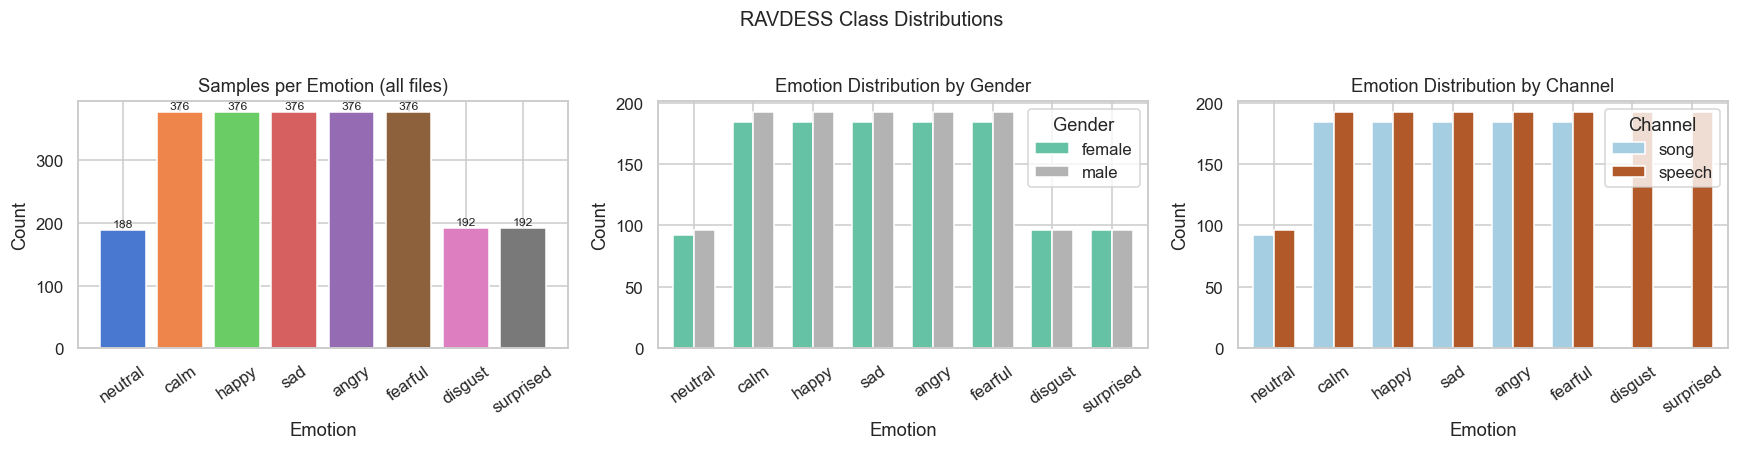

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot A: samples per emotion (speech + song combined) ───────────────────
emotion_counts = df['emotion_label'].value_counts().sort_index()
axes[0].bar(emotion_counts.index, emotion_counts.values,
            color=sns.color_palette('muted', 8))
axes[0].set_title('Samples per Emotion (all files)')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
# Annotate each bar with its count
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=8)

# ── Plot B: emotion breakdown by gender ────────────────────────────────────
gender_pivot = (
    df.groupby(['emotion_label', 'gender'], observed=True)
      .size()
      .unstack()
)
gender_pivot.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.7)
axes[1].set_title('Emotion Distribution by Gender')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Gender')

# ── Plot C: emotion breakdown by vocal channel ─────────────────────────────
channel_pivot = (
    df.groupby(['emotion_label', 'channel_label'], observed=True)
      .size()
      .unstack(fill_value=0)
)
channel_pivot.plot(kind='bar', ax=axes[2], colormap='Paired', width=0.7)
axes[2].set_title('Emotion Distribution by Channel')
axes[2].set_xlabel('Emotion')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=35)
axes[2].legend(title='Channel')

plt.suptitle('RAVDESS Class Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distributions.png'),
            bbox_inches='tight')
plt.show()

## 5. Audio Property Exploration

Load a sample of audio files with librosa and inspect:
- Duration distribution
- Sample rate
- Waveform plots for different emotions

In [32]:
# ── Compute duration for every file ────────────────────────────────────────
# librosa.get_duration(path=...) reads metadata without decoding the audio
print('Computing durations... (this may take ~30 seconds)')

durations = []
for path in df['path']:
    try:
        d = librosa.get_duration(path=path)
    except Exception:
        d = np.nan
    durations.append(d)

df['duration'] = durations

print(f'Duration stats (seconds):')
print(df['duration'].describe().round(2))

Computing durations... (this may take ~30 seconds)
Duration stats (seconds):
count    2452.00
mean        4.09
std         0.60
min         2.94
25%         3.60
50%         4.00
75%         4.54
max         6.37
Name: duration, dtype: float64


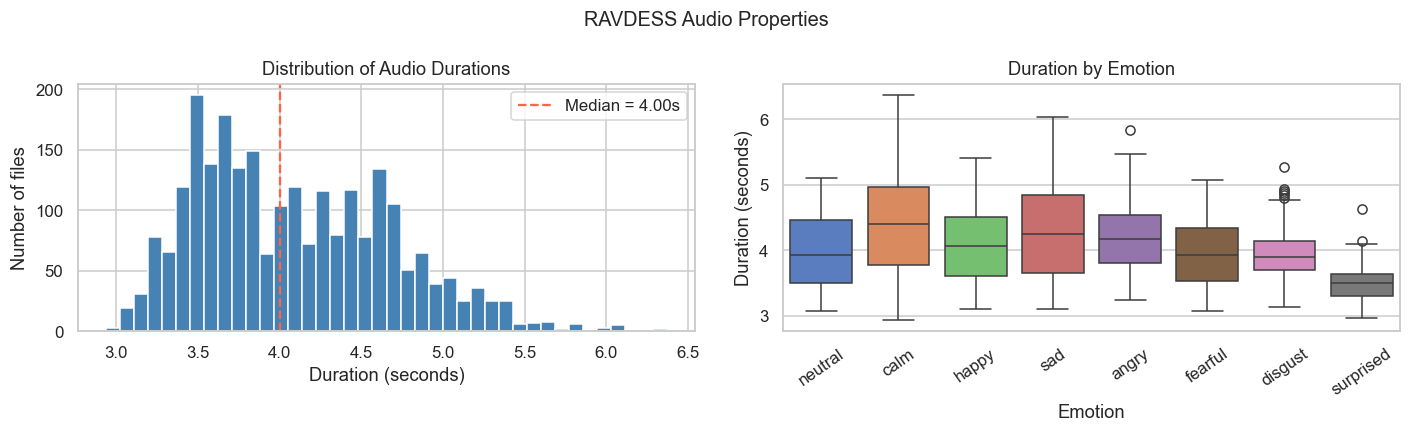

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Plot A: overall duration histogram ─────────────────────────────────────
axes[0].hist(df['duration'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['duration'].median(), color='tomato', linestyle='--',
                label=f'Median = {df["duration"].median():.2f}s')
axes[0].set_title('Distribution of Audio Durations')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Number of files')
axes[0].legend()

# ── Plot B: duration by emotion (boxplot) ──────────────────────────────────
df_sorted = df.copy()
# Use numeric emotion for sorting order, but show labels
emotion_order = [EMOTION_MAP[i] for i in range(1, 9)]
sns.boxplot(
    data=df_sorted, x='emotion_label', y='duration',
    order=emotion_order, palette='muted', ax=axes[1]
)
axes[1].set_title('Duration by Emotion')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Duration (seconds)')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle('RAVDESS Audio Properties', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'audio_properties.png'), bbox_inches='tight')
plt.show()

## 6. Waveform Visualization

Plot one waveform per emotion using a male speech sample.
The waveform shows amplitude over time — a first glimpse at how emotions differ acoustically.

Things to look for:
- **Angry / surprised** tend to have larger amplitude spikes
- **Neutral / calm** tend to be smoother and lower amplitude
- **Fearful** often has irregular, breathy patterns

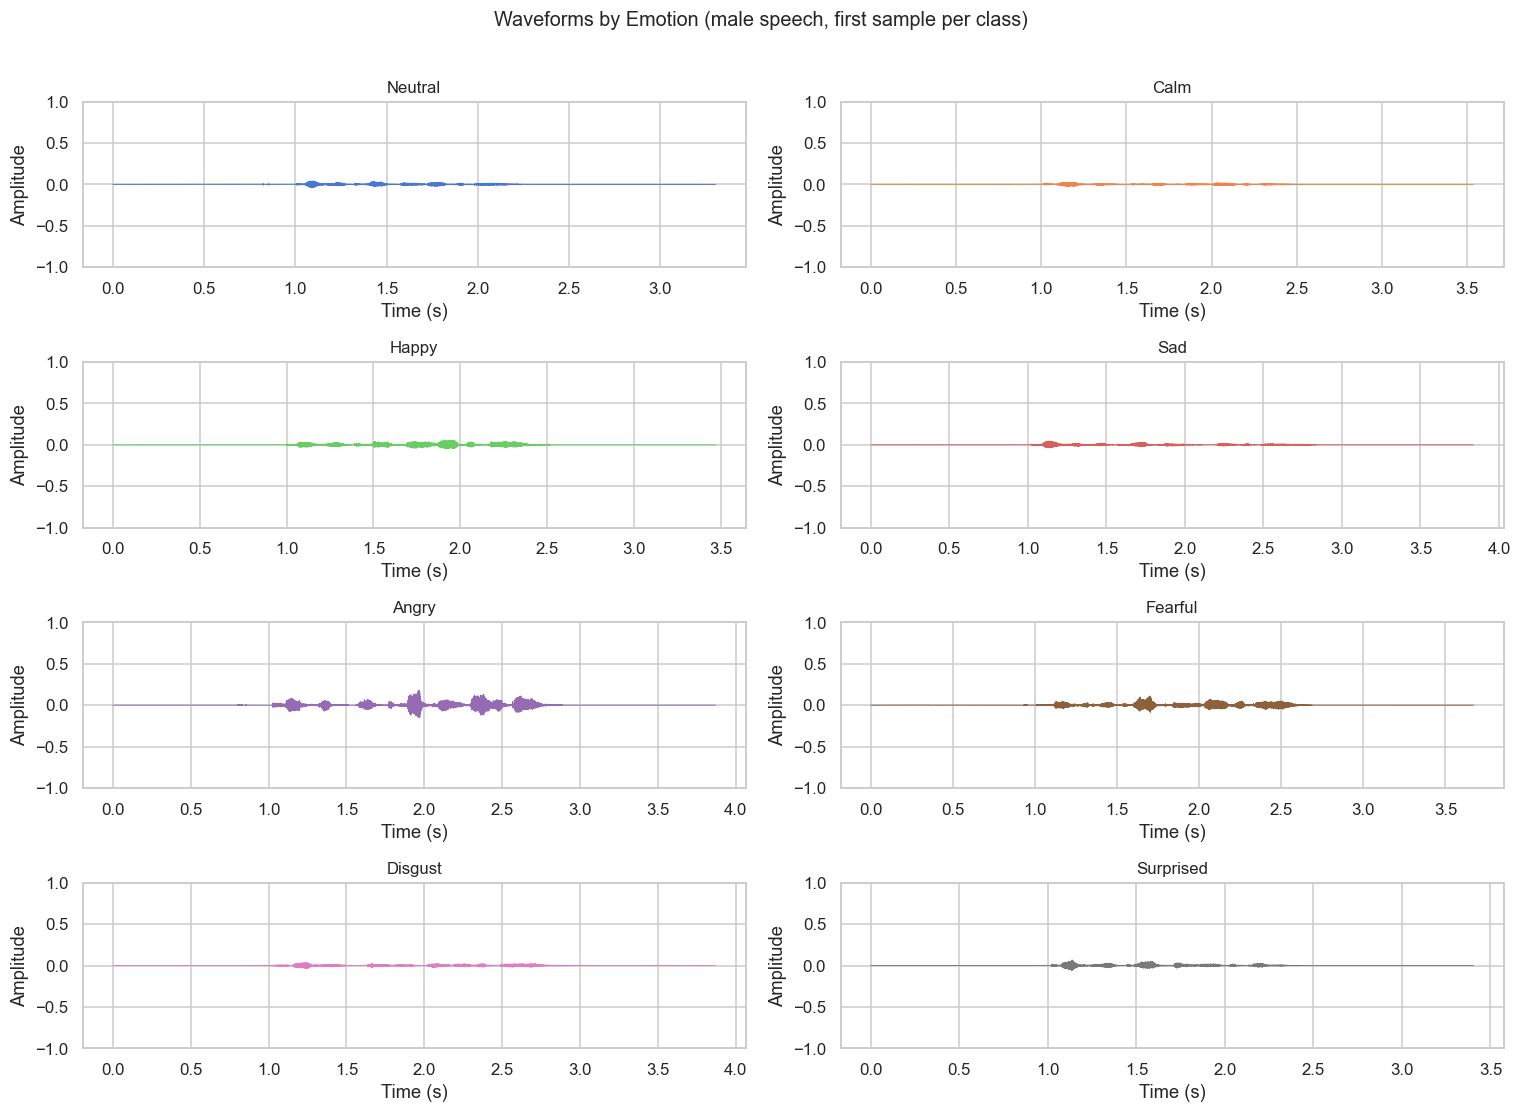

In [34]:
# Pick one male speech sample per emotion for a fair comparison
# (same vocal channel, same gender reduces confounding variables)
sample_df = (
    df[(df.vocal_channel == 1) & (df.gender == 'male')]
      .groupby('emotion_label', observed=True)
      .first()
      .reset_index()
)

emotion_order = [EMOTION_MAP[i] for i in range(1, 9)]
sample_df = sample_df.set_index('emotion_label').loc[emotion_order].reset_index()

fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

for i, row in sample_df.iterrows():
    y, sr = librosa.load(row['path'], sr=None)   # sr=None keeps native 48kHz
    time  = np.linspace(0, len(y) / sr, len(y))

    axes[i].plot(time, y, color=sns.color_palette('muted', 8)[i], linewidth=0.6)
    axes[i].set_title(f'{row["emotion_label"].capitalize()}', fontsize=11)
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude')
    axes[i].set_ylim(-1, 1)

plt.suptitle('Waveforms by Emotion (male speech, first sample per class)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'waveforms.png'), bbox_inches='tight')
plt.show()

## 7. Mel Spectrogram Visualization

A mel spectrogram shows frequency content (y-axis, mel scale) over time (x-axis) for each file.
Brighter colors = more energy at that frequency at that time.

The mel scale compresses high frequencies and expands low frequencies to mimic how the human ear perceives pitch — which is why it's particularly useful for speech and emotion.

Things to look for:
- **Happy / angry** — broad high-frequency energy, fast changes
- **Sad / calm** — concentrated low-frequency energy, slower changes
- **Neutral** — clean harmonic structure, moderate energy

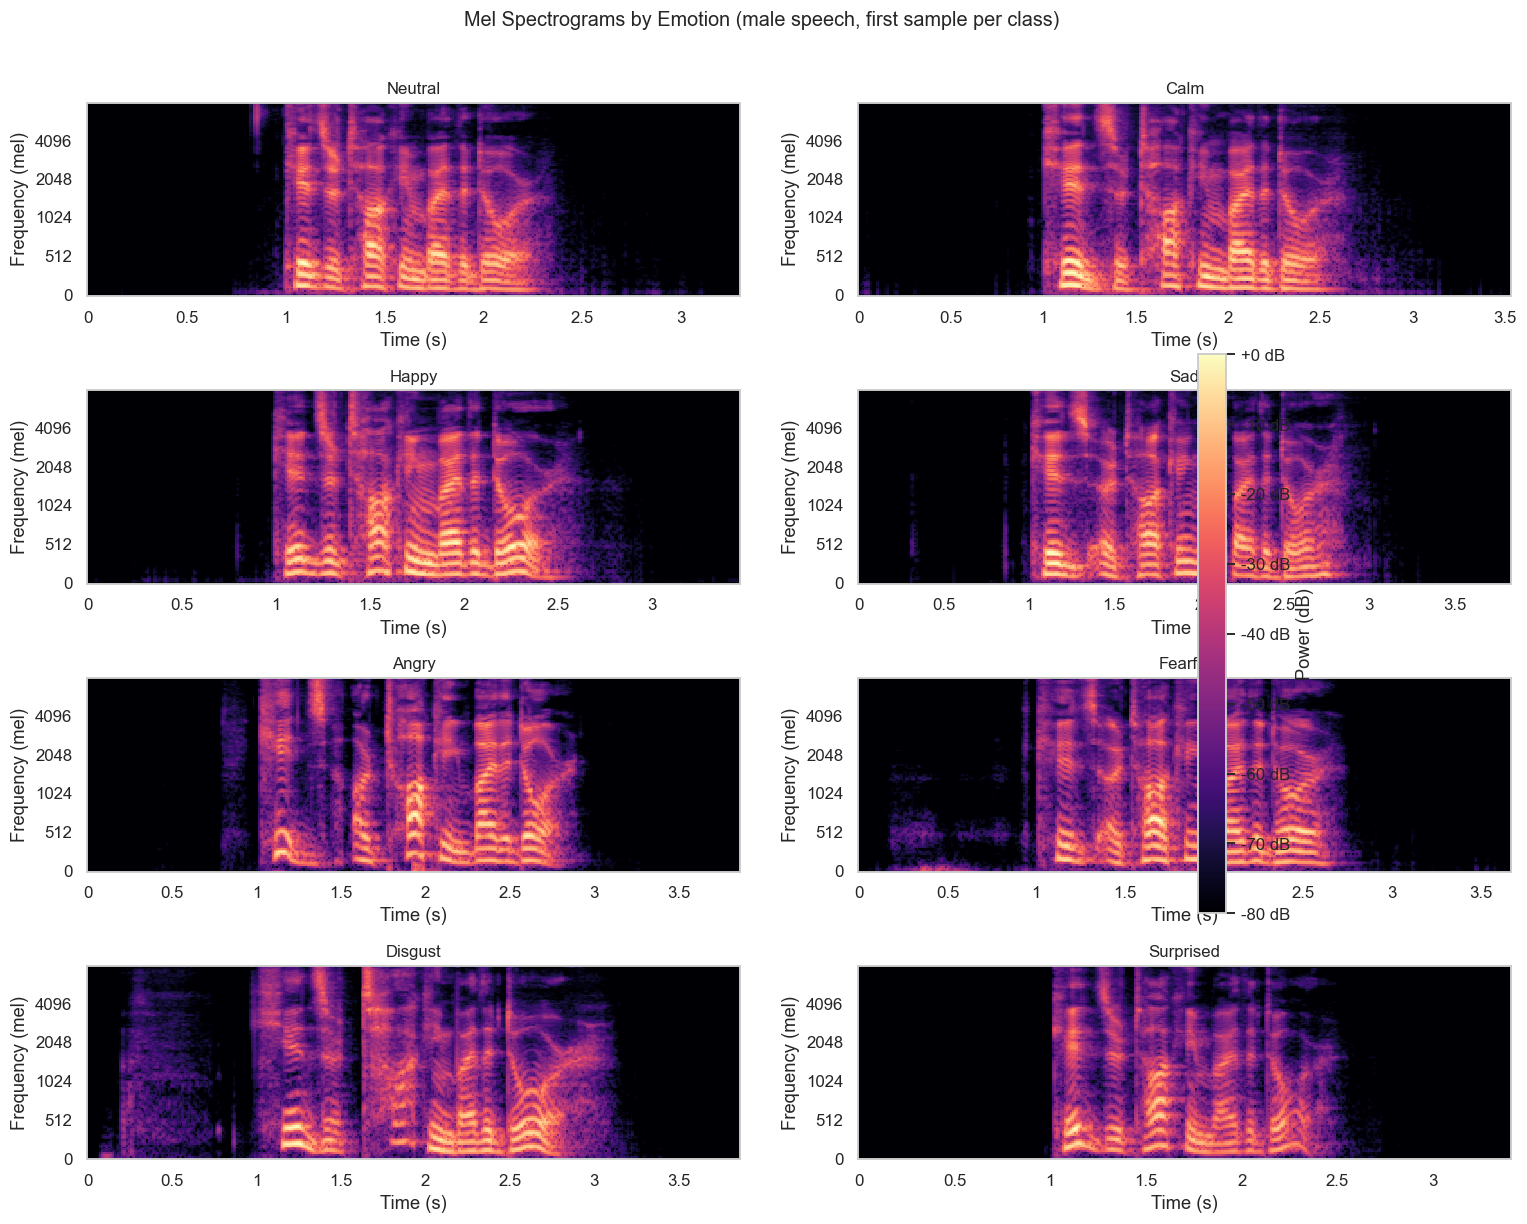

In [35]:
# Reuse the same one-per-emotion male speech samples from section 6
fig, axes = plt.subplots(4, 2, figsize=(14, 11))
axes = axes.flatten()

for i, row in sample_df.iterrows():
    y, sr = librosa.load(row['path'], sr=None)

    # Compute mel spectrogram and convert to dB scale
    # n_mels=128: number of mel frequency bands
    # fmax=8000 : cap at 8kHz — most speech energy lives below here
    S      = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_db   = librosa.power_to_db(S, ref=np.max)   # dB relative to peak power

    img = librosa.display.specshow(
        S_db, sr=sr, x_axis='time', y_axis='mel',
        fmax=8000, ax=axes[i], cmap='magma'
    )
    axes[i].set_title(f'{row["emotion_label"].capitalize()}', fontsize=11)
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Frequency (mel)')

# Shared colorbar
fig.colorbar(img, ax=axes, format='%+2.0f dB', shrink=0.6, label='Power (dB)')

plt.suptitle('Mel Spectrograms by Emotion (male speech, first sample per class)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mel_spectrograms.png'), bbox_inches='tight')
plt.show()

## 5. Discussion

*Write your analysis here.  Address:*
- *How balanced are the classes?  Is neutral underrepresented (it lacks a 'strong' intensity)?*
- *Do speech and song files look visually different in spectrograms?*
- *Any data quality issues (missing files, outlier durations)?*